# C1 Pulse (independent free parameters)

Complex envelope of Formula C1 (carrier $e^{i\omega_0 t}$ removed; residual $e^{-i\omega_0 t_k}$ absorbed in $\theta_k$):

$$
E_{\mathrm{env}}(t)
= \sum_{k=1}^{N_{\mathrm{spikes}}}
A_k
\exp\!\left(-\frac{(t-t_k)^2}{4\sigma_{\mathrm{spike}}^2}\right)
\exp\!\Bigl(i\bigl[\Delta\omega_k(t - t_k) + \theta_k\bigr]\Bigr)
$$

All pulse families below share the same **`T_TOTAL`** and time/spectral grid from the free-parameter cell.
Spike draws are **fresh each run** (no RNG seed).

Plots use a plain $N$-point FFT (no padded / improved spectral resolution). Fields are **not** canonicalized.


In [324]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from data_generation import phase_t_unwrapped_at_index
from frognet import FROGNet
from pulse_metrics import prepare_frog_trace_for_plot

# ==========================================
# FREE PARAMETERS (all independent)
# ==========================================
factor = 1
T_TOTAL = factor * 70.0                 # fs
N_SPIKES = 500
E_0 = 10000.0                   # eV
SIGMA_T_CENTER = factor * 5.73           # fs  (σ_{t,c})
N_POINTS = 64

SIGMA_SPIKE = factor * 1               # fs  (σ_spike); free — not tied to T_TOTAL
DELTA_ENERGY_EV_RANGE = 0.00065 # eV; free — half-width of ΔE draw range
A_MIN, A_MAX = 0.75, 1.0        # A_k ~ U[A_MIN, A_MAX]
PLANCK_CONSTANT_FS_EV = 4.135667696

t = np.linspace(-T_TOTAL / 2, T_TOTAL / 2, N_POINTS)
dt = t[1] - t[0]

omega_0 = E_0 * (2.0 * np.pi) / PLANCK_CONSTANT_FS_EV
DELTA_OMEGA_RELATIVE_RANGE = DELTA_ENERGY_EV_RANGE / E_0
DELTA_OMEGA_MAX = DELTA_OMEGA_RELATIVE_RANGE * omega_0

# Plain N-pt spectral axis (relative energy, centered at E_0)
energy_ev_rel = np.fft.fftshift(np.fft.fftfreq(N_POINTS, d=dt) * PLANCK_CONSTANT_FS_EV)
energy_ev_abs = E_0 + energy_ev_rel

print(f"T_TOTAL={T_TOTAL} fs, N_SPIKES={N_SPIKES}, E_0={E_0} eV")
print(f"σ_t,c={SIGMA_T_CENTER} fs, σ_spike={SIGMA_SPIKE} fs, N_POINTS={N_POINTS}")
print(f"dt={dt:.4f} fs, Δω_max={DELTA_OMEGA_MAX:.6e} rad/fs")
print(f"Spectral bin spacing (legacy) dE={energy_ev_rel[1]-energy_ev_rel[0]:.6f} eV")

def build_c1_envelope(*, n_spikes, sigma_spike, sigma_t_c, delta_omega_max, use_delta_omega=True):
    """One random multi-spike field on the shared (t, N_POINTS) grid. No seed."""
    f = np.zeros(N_POINTS, dtype=complex)
    for _ in range(int(n_spikes)):
        t_center = np.random.normal(loc=0.0, scale=sigma_t_c)
        amplitude = np.random.uniform(A_MIN, A_MAX)
        random_phase = np.random.uniform(-np.pi, np.pi)
        dwi = (
            np.random.uniform(-delta_omega_max, delta_omega_max)
            if use_delta_omega
            else 0.0
        )
        dt_k = t - t_center
        env = np.exp(-(dt_k ** 2) / (4.0 * sigma_spike ** 2))
        phase = dwi * dt_k + random_phase
        f += amplitude * env * np.exp(1j * phase)
    return f


def spectrum_from_time(f_t_field):
    return np.fft.fftshift(np.fft.fft(f_t_field))


T_TOTAL=70.0 fs, N_SPIKES=500, E_0=10000.0 eV
σ_t,c=5.73 fs, σ_spike=1 fs, N_POINTS=64
dt=1.1111 fs, Δω_max=9.875238e-04 rad/fs
Spectral bin spacing (legacy) dE=0.058158 eV


## 1. Build C1 envelope field

In [325]:
spike_params = []
for _ in range(N_SPIKES):
    spike_params.append({
        "t_center": np.random.normal(loc=0.0, scale=SIGMA_T_CENTER),
        "amplitude": np.random.uniform(A_MIN, A_MAX),
        "random_phase": np.random.uniform(-np.pi, np.pi),
        "delta_omega_i": np.random.uniform(-DELTA_OMEGA_MAX, DELTA_OMEGA_MAX),
    })

f_t = np.zeros(N_POINTS, dtype=complex)
for p in spike_params:
    dt_k = t - p["t_center"]
    env = np.exp(-(dt_k ** 2) / (4.0 * SIGMA_SPIKE ** 2))
    phase = p["delta_omega_i"] * dt_k + p["random_phase"]
    f_t += p["amplitude"] * env * np.exp(1j * phase)

f_v = np.fft.fftshift(np.fft.fft(f_t))

print(f"||E(t)||_2 = {np.linalg.norm(f_t):.4f}")
print(f"max |E(t)| = {np.max(np.abs(f_t)):.4f}")

||E(t)||_2 = 18.8466
max |E(t)| = 7.8694


## 2. Amplitude & phase (time + spectrum)

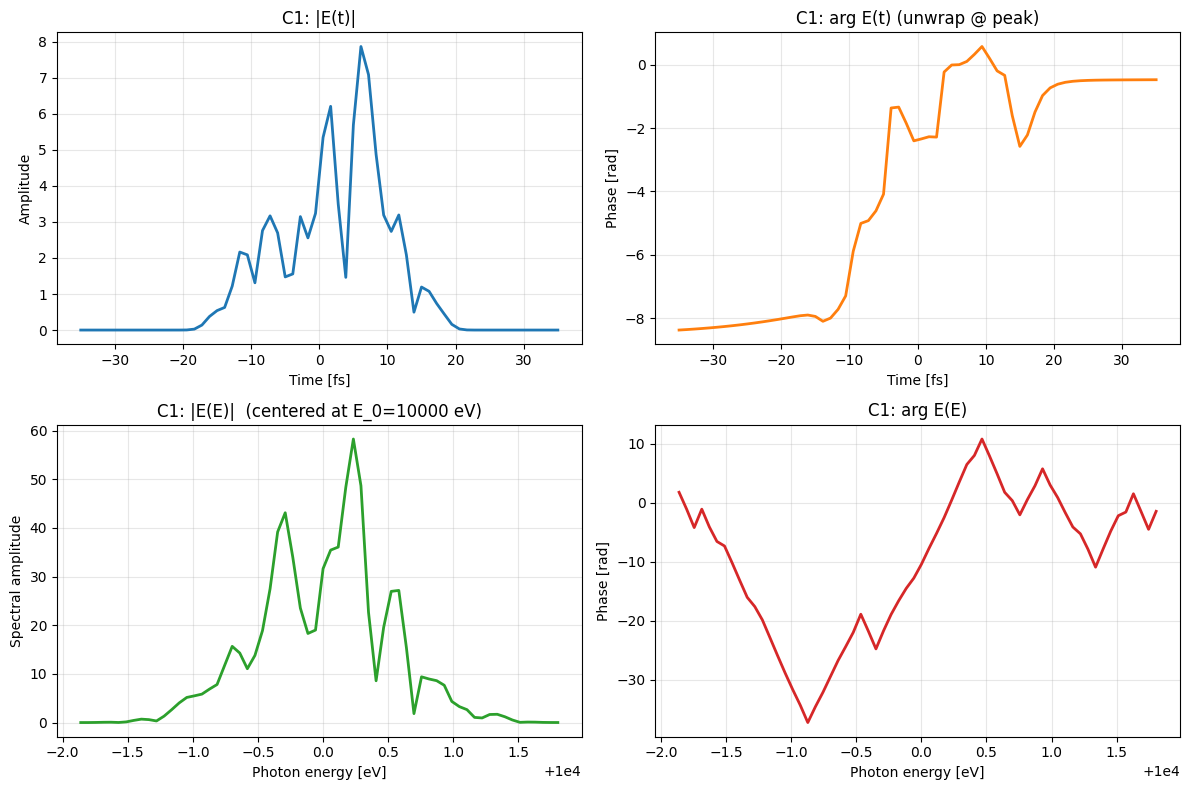

In [326]:
def plot_amp_phase(f_t_field, f_v_field, title_prefix):
    t_peak = int(np.argmax(np.abs(f_t_field)))
    amp_t = np.abs(f_t_field)
    phase_t = phase_t_unwrapped_at_index(f_t_field, t_peak)
    amp_v = np.abs(f_v_field)
    phase_v = np.unwrap(np.angle(f_v_field))

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    axs[0, 0].plot(t, amp_t, lw=2)
    axs[0, 0].set_title(f"{title_prefix}: |E(t)|")
    axs[0, 0].set_xlabel("Time [fs]")
    axs[0, 0].set_ylabel("Amplitude")
    axs[0, 0].grid(True, alpha=0.3)

    axs[0, 1].plot(t, phase_t, lw=2, color="C1")
    axs[0, 1].set_title(f"{title_prefix}: arg E(t) (unwrap @ peak)")
    axs[0, 1].set_xlabel("Time [fs]")
    axs[0, 1].set_ylabel("Phase [rad]")
    axs[0, 1].grid(True, alpha=0.3)

    axs[1, 0].plot(energy_ev_abs, amp_v, lw=2, color="C2")
    axs[1, 0].set_title(f"{title_prefix}: |E(E)|  (centered at E_0={E_0:g} eV)")
    axs[1, 0].set_xlabel("Photon energy [eV]")
    axs[1, 0].set_ylabel("Spectral amplitude")
    axs[1, 0].grid(True, alpha=0.3)

    axs[1, 1].plot(energy_ev_abs, phase_v, lw=2, color="C3")
    axs[1, 1].set_title(f"{title_prefix}: arg E(E)")
    axs[1, 1].set_xlabel("Photon energy [eV]")
    axs[1, 1].set_ylabel("Phase [rad]")
    axs[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_amp_phase(f_t, f_v, "C1")

## 3. Real & imaginary parts (time + spectrum)

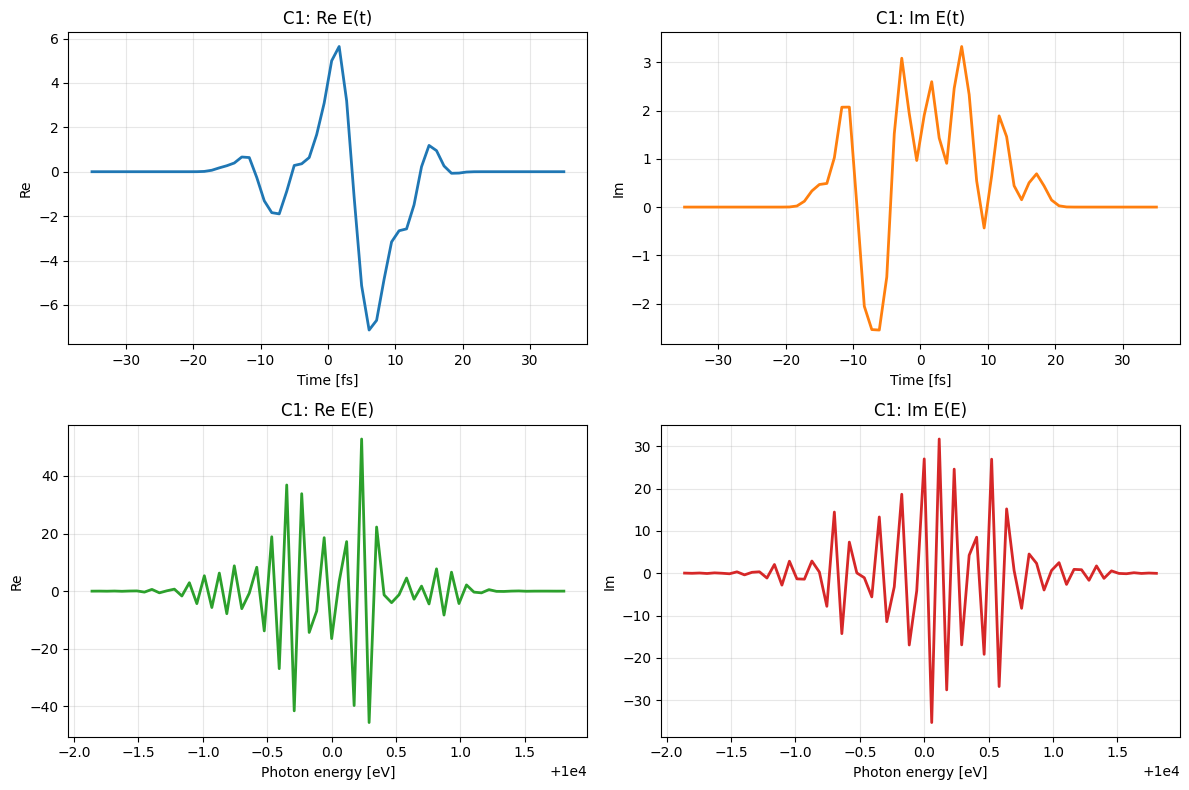

In [327]:
def plot_re_im(f_t_field, f_v_field, title_prefix):
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    axs[0, 0].plot(t, f_t_field.real, lw=2)
    axs[0, 0].set_title(f"{title_prefix}: Re E(t)")
    axs[0, 0].set_xlabel("Time [fs]")
    axs[0, 0].set_ylabel("Re")
    axs[0, 0].grid(True, alpha=0.3)

    axs[0, 1].plot(t, f_t_field.imag, lw=2, color="C1")
    axs[0, 1].set_title(f"{title_prefix}: Im E(t)")
    axs[0, 1].set_xlabel("Time [fs]")
    axs[0, 1].set_ylabel("Im")
    axs[0, 1].grid(True, alpha=0.3)

    axs[1, 0].plot(energy_ev_abs, f_v_field.real, lw=2, color="C2")
    axs[1, 0].set_title(f"{title_prefix}: Re E(E)")
    axs[1, 0].set_xlabel("Photon energy [eV]")
    axs[1, 0].set_ylabel("Re")
    axs[1, 0].grid(True, alpha=0.3)

    axs[1, 1].plot(energy_ev_abs, f_v_field.imag, lw=2, color="C3")
    axs[1, 1].set_title(f"{title_prefix}: Im E(E)")
    axs[1, 1].set_xlabel("Photon energy [eV]")
    axs[1, 1].set_ylabel("Im")
    axs[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_re_im(f_t, f_v, "C1")


## 4. SHG-FROG TRACE

Frequency axis shown as **relative energy** [eV] (offset from $E_0$).

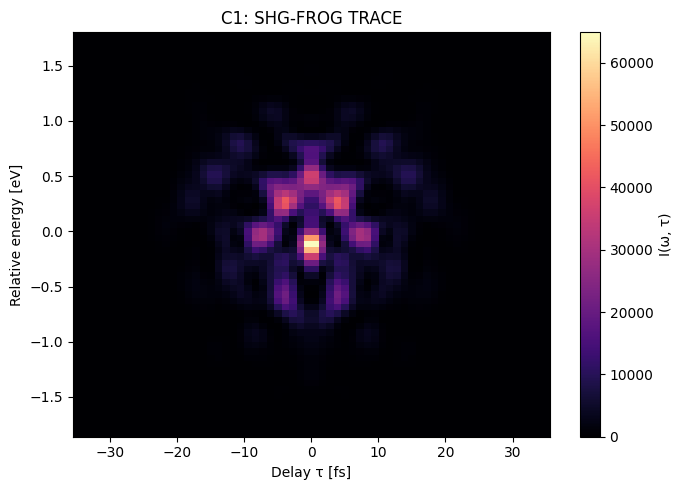

In [328]:
def plot_frog(f_t_field, title_prefix):
    frog = FROGNet(num_delay_steps=len(t))
    frog.eval()
    with torch.no_grad():
        e = torch.from_numpy(f_t_field.astype(np.complex64)).unsqueeze(0)
        trace = frog(e).squeeze(0).cpu().numpy()

    trace_plot, tau_axis, omega_plot = prepare_frog_trace_for_plot(
        trace, num_points=N_POINTS, dt=dt
    )
    energy_plot = omega_plot * PLANCK_CONSTANT_FS_EV / (2.0 * np.pi)

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(
        trace_plot,
        origin="lower",
        aspect="auto",
        extent=[tau_axis[0], tau_axis[-1], energy_plot[0], energy_plot[-1]],
        cmap="magma",
    )
    ax.set_title(f"{title_prefix}: SHG-FROG TRACE")
    ax.set_xlabel("Delay τ [fs]")
    ax.set_ylabel("Relative energy [eV]")
    fig.colorbar(im, ax=ax, label="I(ω, τ)")
    plt.tight_layout()
    plt.show()


plot_frog(f_t, "C1")

# Spectral Gaussian envelope on C1

Take the same C1 field, FFT → multiply the **complex spectrum** by a Gaussian of FWHM $=0.5$ eV centered at $E_0$ (i.e. at $E_{\mathrm{rel}}=0$), then IFFT back to time:

$$
G(E) = \exp\!\left(-\frac{(E-E_0)^2}{2\sigma_E^2}\right),
\qquad
\sigma_E = \frac{\mathrm{FWHM}}{2\sqrt{2\ln 2}}
$$

$$
\tilde{E}_{\mathrm{filt}}(E) = \tilde{E}_{\mathrm{C1}}(E)\,G(E),
\qquad
E_{\mathrm{filt}}(t) = \mathrm{IFFT}\big[\tilde{E}_{\mathrm{filt}}\big]
$$

Same plot suite as above (no canonicalization; plain $N$-pt FFT).

FWHM=0.45 eV → σ_E=0.191097 eV
||E_filt(t)||_2 = 9.9988
max |E_filt(t)| = 3.5556


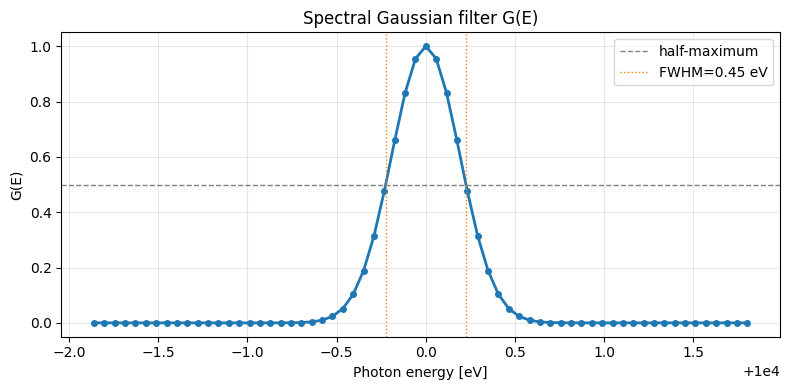

In [329]:
FWHM_EV = 0.45 / factor  # free parameter: spectral Gaussian FWHM [eV]
SIGMA_E = FWHM_EV / (2.0 * np.sqrt(2.0 * np.log(2.0)))

G = np.exp(-(energy_ev_rel ** 2) / (2.0 * SIGMA_E ** 2))
f_v_filt = f_v * G
f_t_filt = np.fft.ifft(np.fft.ifftshift(f_v_filt))

print(f"FWHM={FWHM_EV} eV → σ_E={SIGMA_E:.6f} eV")
print(f"||E_filt(t)||_2 = {np.linalg.norm(f_t_filt):.4f}")
print(f"max |E_filt(t)| = {np.max(np.abs(f_t_filt)):.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(energy_ev_abs, G, lw=2, marker="o", markersize=4)
ax.axhline(0.5, color="gray", ls="--", lw=1, label="half-maximum")
ax.axvline(E_0 - FWHM_EV / 2, color="C1", ls=":", lw=1)
ax.axvline(E_0 + FWHM_EV / 2, color="C1", ls=":", lw=1, label=f"FWHM={FWHM_EV} eV")
ax.set_title("Spectral Gaussian filter G(E)")
ax.set_xlabel("Photon energy [eV]")
ax.set_ylabel("G(E)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Amplitude & phase (filtered)

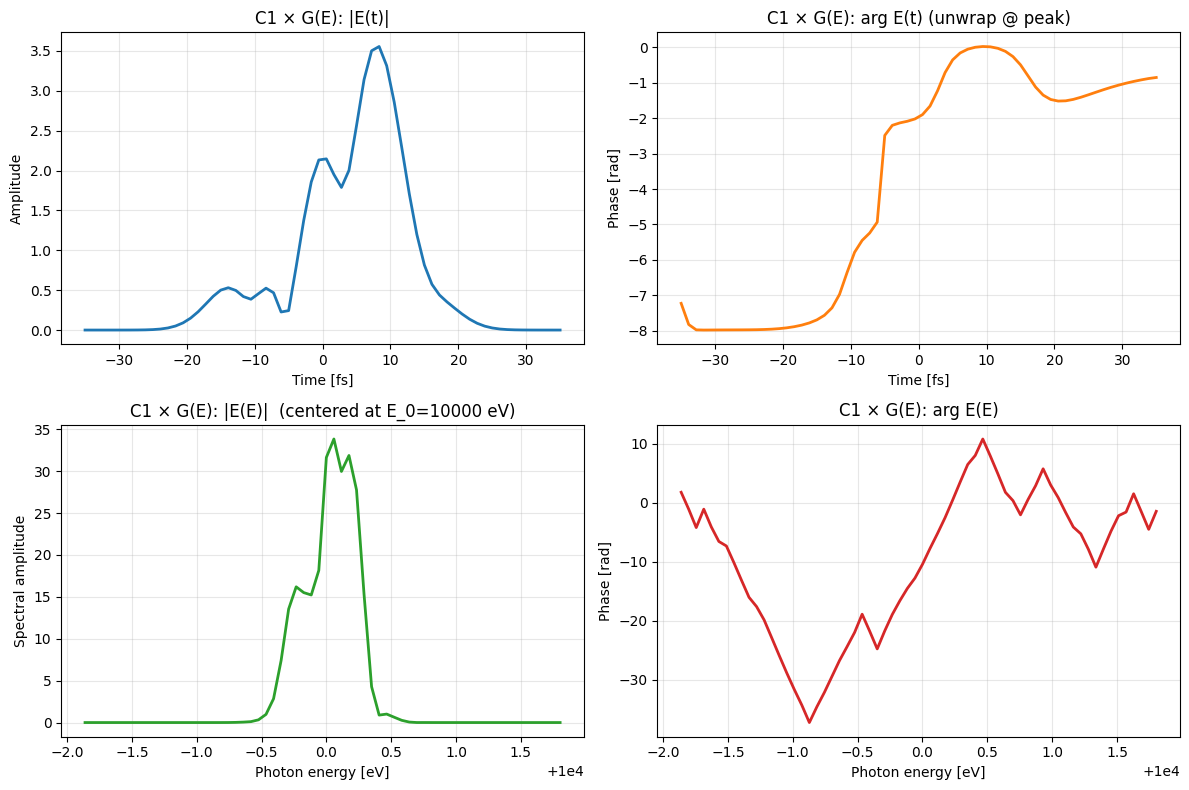

In [330]:
plot_amp_phase(f_t_filt, f_v_filt, "C1 × G(E)")

## 6. Real & imaginary parts (filtered)

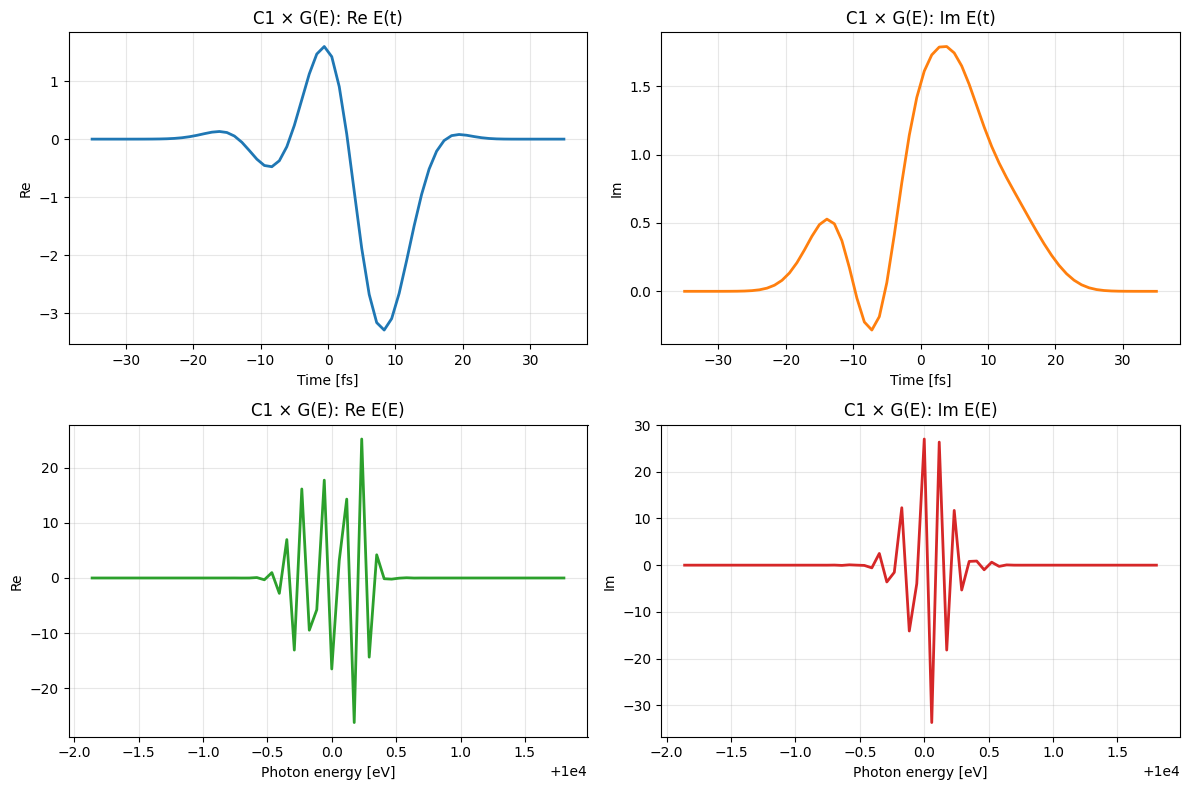

In [331]:
plot_re_im(f_t_filt, f_v_filt, "C1 × G(E)")

## 7. SHG-FROG TRACE (filtered)

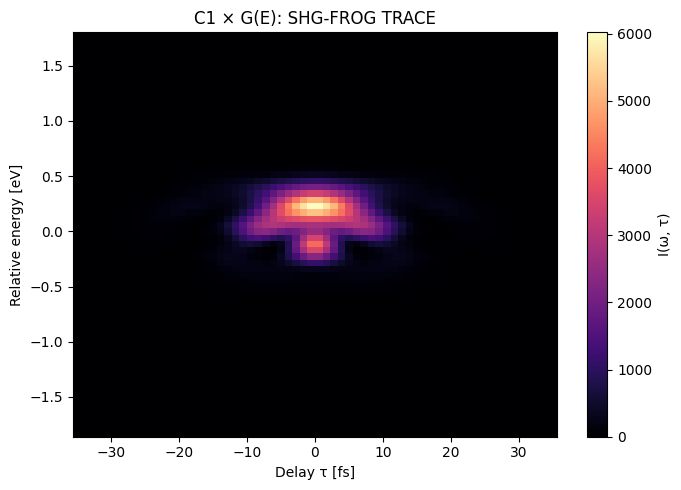

In [332]:
plot_frog(f_t_filt, "C1 × G(E)")

# Data C pulse (diagnostics / Multires Data C)

Same **modified C1** as `data_c_amb_loss_diagnostics_NB.ipynb` / Data C in
`stochastic_multires_2k_noisy_trace_lambda_experiments.ipynb`
(`StochasticPulseConfig` with `t_center_std_fs=9.5`), except **`T_TOTAL` is the shared notebook value**
(not forced to 100 fs).

| param | value |
|-------|-------|
| $T$ | shared `T_TOTAL` |
| $N$ | shared `N_POINTS` |
| $N_{\mathrm{spikes}}$ | 30 |
| $\sigma_{\mathrm{spike}}$ ($\tau_c$) | 2.5 fs |
| $\sigma_{t,c}$ | **9.5 fs** |
| $A_k$ | $\mathcal{U}[0.75,1.0]$ |
| $\theta_k$ | $\mathcal{U}[-\pi,+\pi]$ (constant phase; **no** $\Delta\omega_k$ in phase) |
| $E_0$ | shared `E_0` |

Fresh draw every run. No canonicalization.


In [333]:
# Data C — modified C1 (wider σ_t,c), shared T_TOTAL grid
N_SPIKES_C = 30
SIGMA_SPIKE_C = 2.5
SIGMA_TC_C = 9.5

f_t_c = build_c1_envelope(
    n_spikes=N_SPIKES_C,
    sigma_spike=SIGMA_SPIKE_C,
    sigma_t_c=SIGMA_TC_C,
    delta_omega_max=DELTA_OMEGA_MAX,
    use_delta_omega=False,
)
f_v_c = spectrum_from_time(f_t_c)

print(
    f"Data C: T={T_TOTAL} fs, N_spikes={N_SPIKES_C}, "
    f"σ_spike={SIGMA_SPIKE_C} fs, σ_t,c={SIGMA_TC_C} fs"
)
print(f"  ||E||_2={np.linalg.norm(f_t_c):.4f}, max|E|={np.max(np.abs(f_t_c)):.4f}")


Data C: T=70.0 fs, N_spikes=30, σ_spike=2.5 fs, σ_t,c=9.5 fs
  ||E||_2=8.0496, max|E|=2.5864


## Data C — amplitude & phase


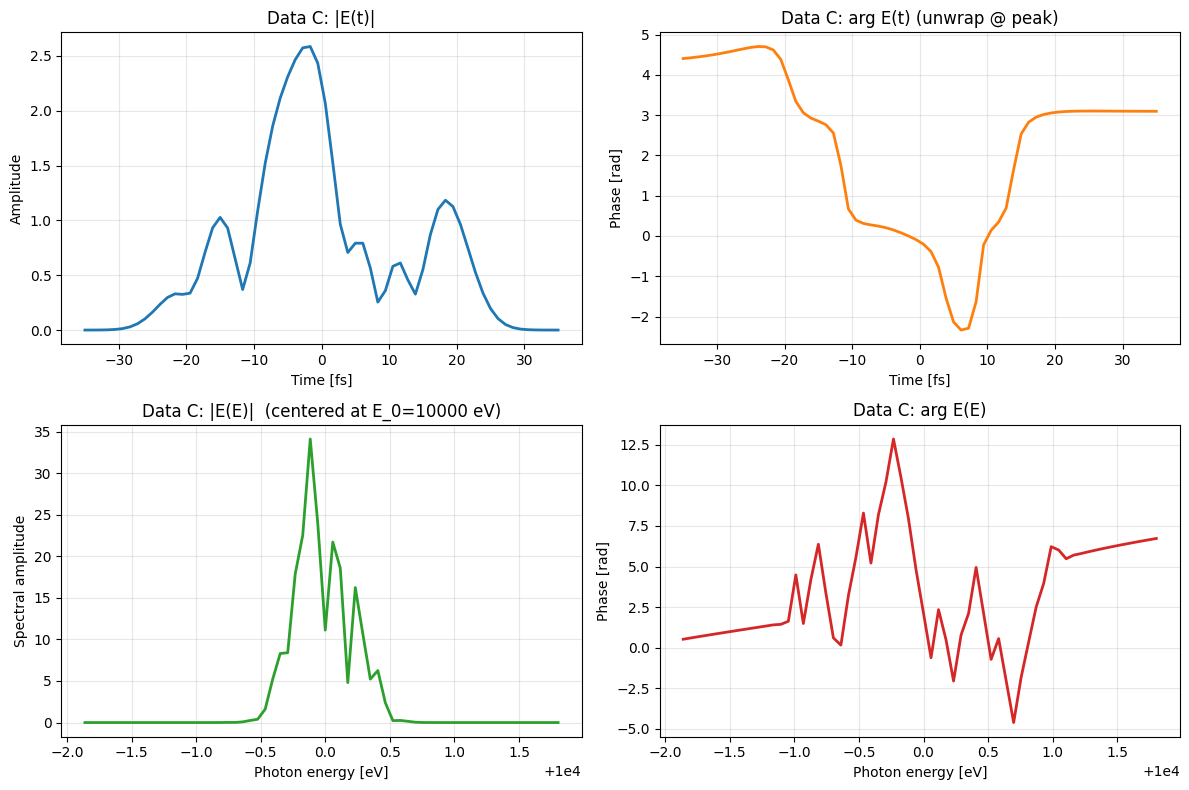

In [334]:
plot_amp_phase(f_t_c, f_v_c, "Data C")


## Data C — Re / Im


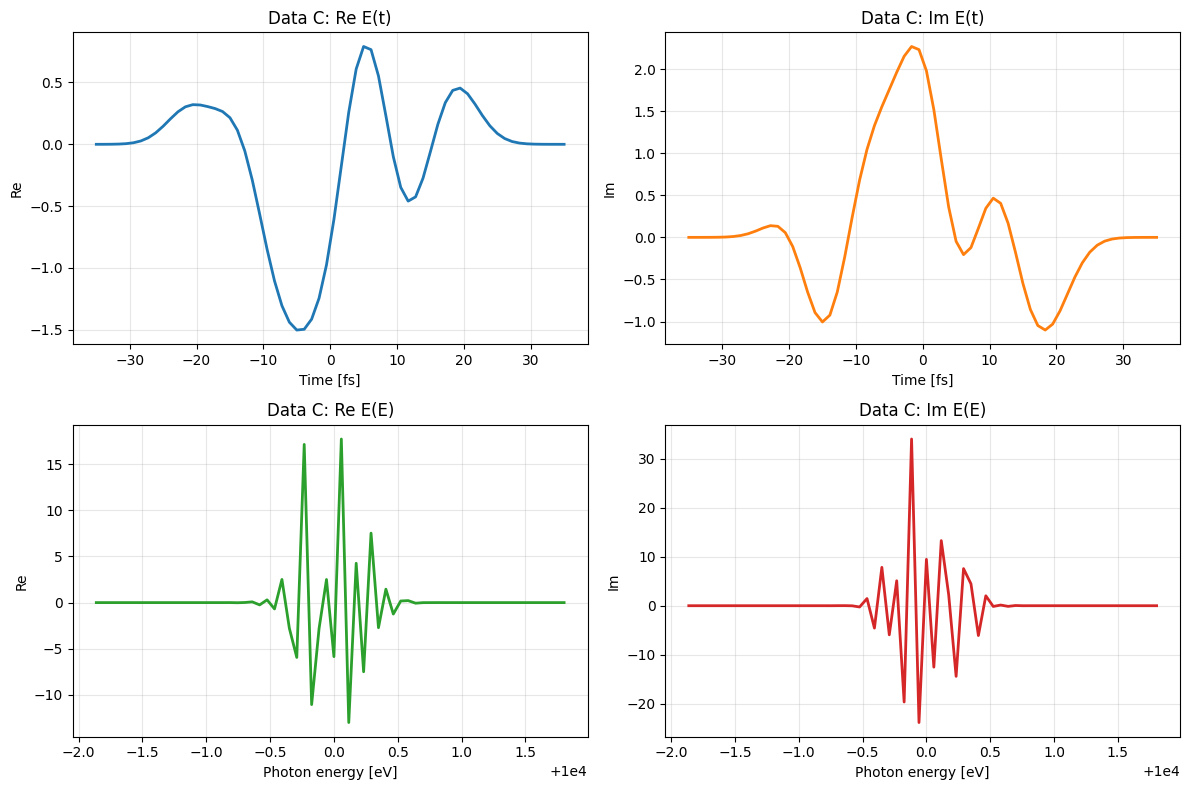

In [335]:
plot_re_im(f_t_c, f_v_c, "Data C")


## Data C — SHG-FROG TRACE


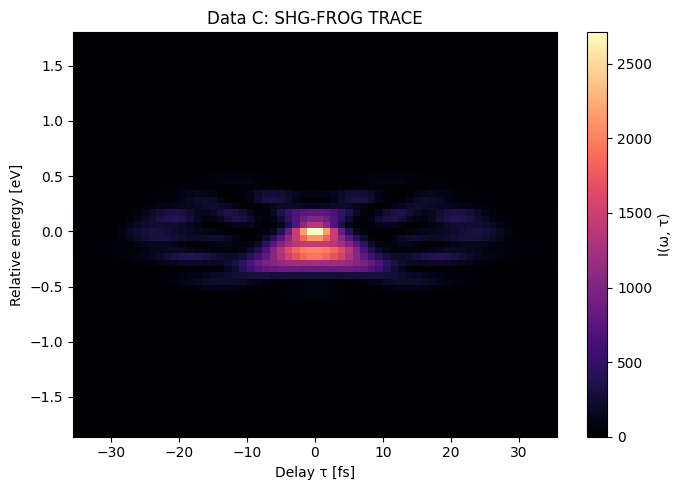

In [336]:
plot_frog(f_t_c, "Data C")


# Data A pulse (Experiment A / Multires)

Same **modified C1** as Experiment A in
`stochastic_multires_2k_noisy_trace_lambda_experiments.ipynb`
(default `StochasticPulseConfig`), except **`T_TOTAL` is the shared notebook value**.

| param | value |
|-------|-------|
| $T$ | shared `T_TOTAL` |
| $N$ | shared `N_POINTS` |
| $N_{\mathrm{spikes}}$ | 30 |
| $\sigma_{\mathrm{spike}}$ ($\tau_c$) | 2.5 fs |
| $\sigma_{t,c}$ | **5.73 fs** |
| $A_k$ | $\mathcal{U}[0.75,1.0]$ |
| $\theta_k$ | $\mathcal{U}[-\pi,+\pi]$ (constant phase; **no** $\Delta\omega_k$ in phase) |
| $E_0$ | shared `E_0` |

Fresh draw every run. No canonicalization.


In [337]:
# Data A — modified C1 (Exp A defaults), shared T_TOTAL grid
N_SPIKES_A = 30
SIGMA_SPIKE_A = 2.5
SIGMA_TC_A = 5.73

f_t_a = build_c1_envelope(
    n_spikes=N_SPIKES_A,
    sigma_spike=SIGMA_SPIKE_A,
    sigma_t_c=SIGMA_TC_A,
    delta_omega_max=DELTA_OMEGA_MAX,
    use_delta_omega=False,
)
f_v_a = spectrum_from_time(f_t_a)

print(
    f"Data A: T={T_TOTAL} fs, N_spikes={N_SPIKES_A}, "
    f"σ_spike={SIGMA_SPIKE_A} fs, σ_t,c={SIGMA_TC_A} fs"
)
print(f"  ||E||_2={np.linalg.norm(f_t_a):.4f}, max|E|={np.max(np.abs(f_t_a)):.4f})")


Data A: T=70.0 fs, N_spikes=30, σ_spike=2.5 fs, σ_t,c=5.73 fs
  ||E||_2=10.5611, max|E|=4.4564)


## Data A — amplitude & phase


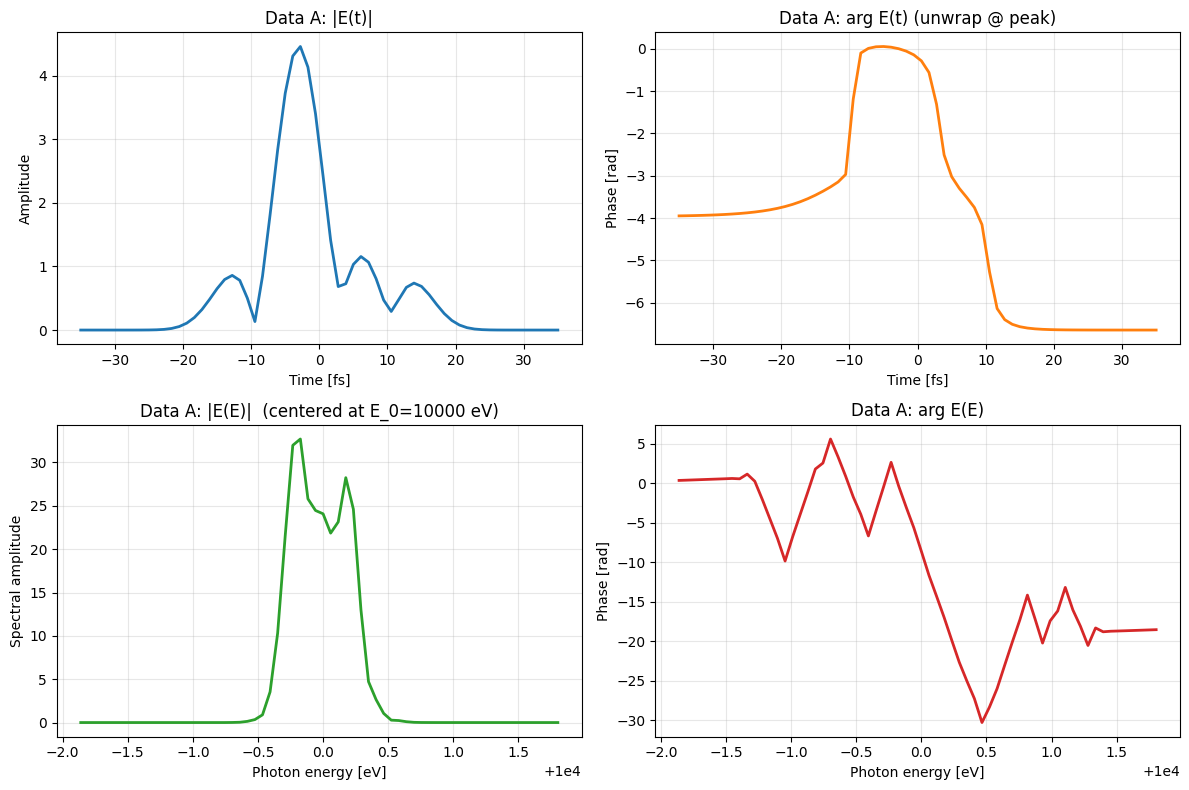

In [338]:
plot_amp_phase(f_t_a, f_v_a, "Data A")


## Data A — Re / Im


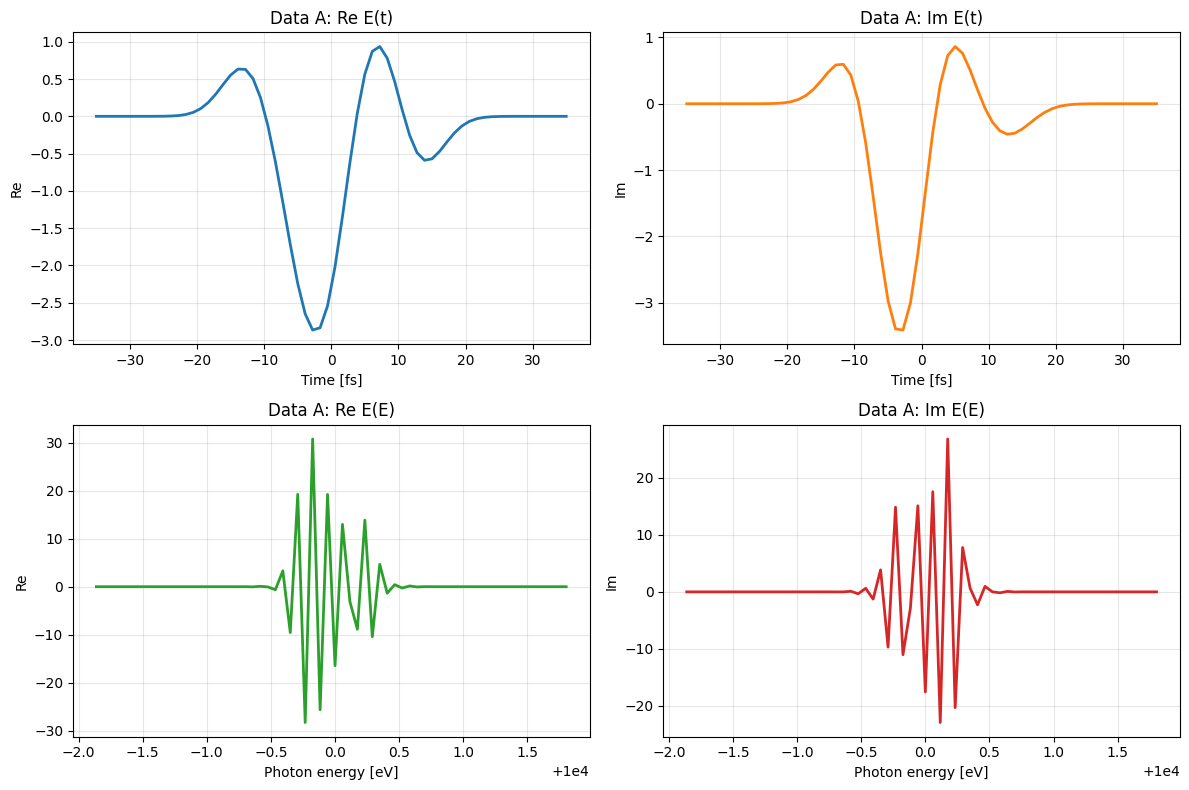

In [339]:
plot_re_im(f_t_a, f_v_a, "Data A")


## Data A — SHG-FROG TRACE


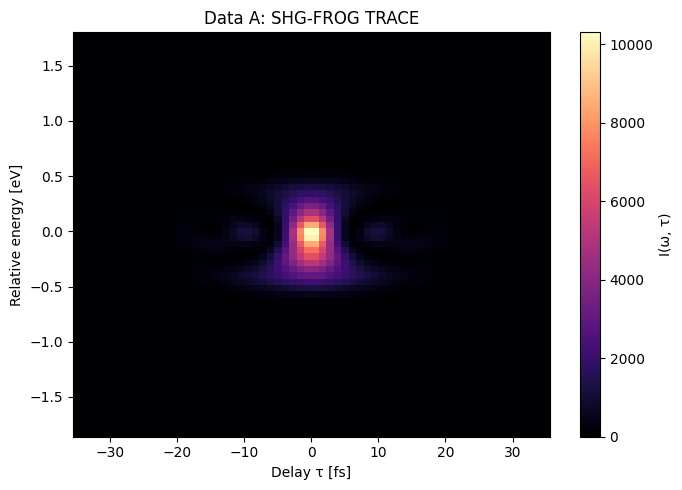

In [340]:
plot_frog(f_t_a, "Data A")
